# Treino do modelo — exploração e gráficos

Este notebook **não reimplementa** feature engineering nem treino — ele chama
`src/models/train.py`, que é a fonte única de verdade, e usa o resultado para
gerar os gráficos em `outputs/`. Se algo aqui parecer errado, o lugar certo
para corrigir é `src/features/engineer.py` ou `src/models/train.py`, nunca
uma célula deste notebook — outra célula rodando por cima resolveria o
sintoma aqui, mas o `python -m src.models.train` da linha de comando (que é o
que o app de verdade usa) continuaria com o problema.

Rodar `python -m src.models.train` na CLI faz exatamente o que a célula
abaixo faz, e já grava `models/xgb_model.pkl` e `data/test_predictions.parquet`
sozinho — abrir este notebook é só para olhar os gráficos.

In [1]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import shap


def find_project_root(marker: str = "CLAUDE.md") -> Path:
    here = Path.cwd().resolve()
    for candidate in (here, *here.parents):
        if (candidate / marker).exists():
            return candidate
    raise RuntimeError(f"could not find {marker} at or above {here}")


BASE_PATH = Path(os.environ.get("TRANSFER_EDGE_ROOT") or find_project_root())
sys.path.insert(0, str(BASE_PATH))
OUTPUTS_DIR = BASE_PATH / "outputs"
OUTPUTS_DIR.mkdir(exist_ok=True)

print(f"project root: {BASE_PATH}")

project root: /Users/luccagazotto/Documents/Personal/ML Projects/Soccer player/Soccer_player_market_value


## 1. Treinar o modelo

Chama `src.models.train.main()` — Ridge baseline, XGBoost, e salva
`models/xgb_model.pkl` + `data/test_predictions.parquet`, exatamente como
`python -m src.models.train` na linha de comando. `model` e `results` voltam
prontos para os gráficos abaixo; `results` é o conjunto de teste com
`pred_value` e `error_pct` já calculados.

In [2]:
from src.models.train import main as train_main

model, results = train_main()

Train: 2912   Val: 623   Test: 1942

=== RIDGE BASELINE ===
  Train    R²=0.645  RMSE(log)=0.962  MAE(log)=0.716  MAPE(€)=47.8%
  Val      R²=0.637  RMSE(log)=1.041  MAE(log)=0.727  MAPE(€)=44.6%
  Test     R²=0.611  RMSE(log)=1.110  MAE(log)=0.809  MAPE(€)=50.2%

=== XGBOOST ===
  Train    R²=0.866  RMSE(log)=0.590  MAE(log)=0.374  MAPE(€)=19.9%
  Val      R²=0.820  RMSE(log)=0.733  MAE(log)=0.444  MAPE(€)=20.8%
  Test     R²=0.819  RMSE(log)=0.757  MAE(log)=0.481  MAPE(€)=24.6%

Saved models/xgb_model.pkl and data/test_predictions.parquet (1942 rows)


## 2. Comparação Visual — Predito vs Real

Em escala log, porque é nessa escala que o modelo é treinado e onde os erros
são proporcionalmente comparáveis entre um jogador de €1M e um de €100M.

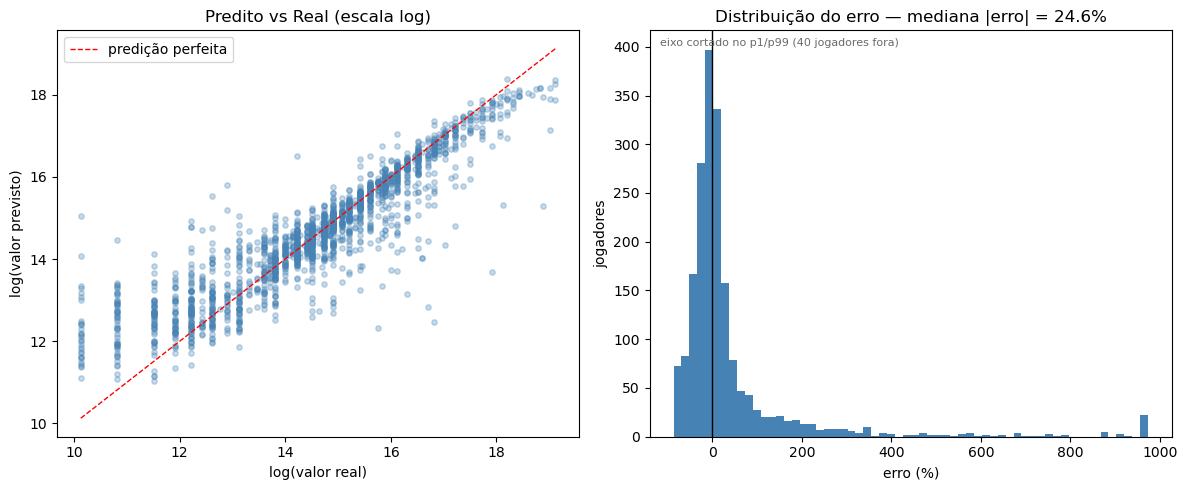

In [3]:
true_log = np.log(results["market_value"])
pred_log = results["pred_log"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.scatter(true_log, pred_log, alpha=0.3, s=15, color="steelblue")
lims = [min(true_log.min(), pred_log.min()), max(true_log.max(), pred_log.max())]
ax.plot(lims, lims, "r--", linewidth=1, label="predição perfeita")
ax.set_xlabel("log(valor real)")
ax.set_ylabel("log(valor previsto)")
ax.set_title("Predito vs Real (escala log)")
ax.legend()

# error_pct has a long tail (young/fringe players with a near-zero TM value
# produce huge % errors from a small absolute miss) — a few points can span
# thousands of percent and would otherwise flatten the whole histogram into
# one spike at zero. Clip the *view*, not the data, and say how many are cut.
lo, hi = results["error_pct"].quantile([0.01, 0.99])
clipped = results["error_pct"].clip(lo, hi)
n_outside = ((results["error_pct"] < lo) | (results["error_pct"] > hi)).sum()

ax = axes[1]
ax.hist(clipped, bins=60, color="steelblue")
ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("erro (%)")
ax.set_ylabel("jogadores")
ax.set_title(f"Distribuição do erro — mediana |erro| = {results['error_pct'].abs().median():.1f}%")
ax.text(0.02, 0.98, f"eixo cortado no p1/p99 ({n_outside} jogadores fora)",
        transform=ax.transAxes, va="top", fontsize=8, color="dimgray")

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "pred_vs_real.png", dpi=150)
plt.show()

## 3. Interpretabilidade — SHAP

`select_features()` reconstrói exatamente a mesma matriz de 44 colunas usada
dentro do treino — é a função que já lida com one-hot ausente e ordem de
colunas, então não há por que montar isso à mão aqui.

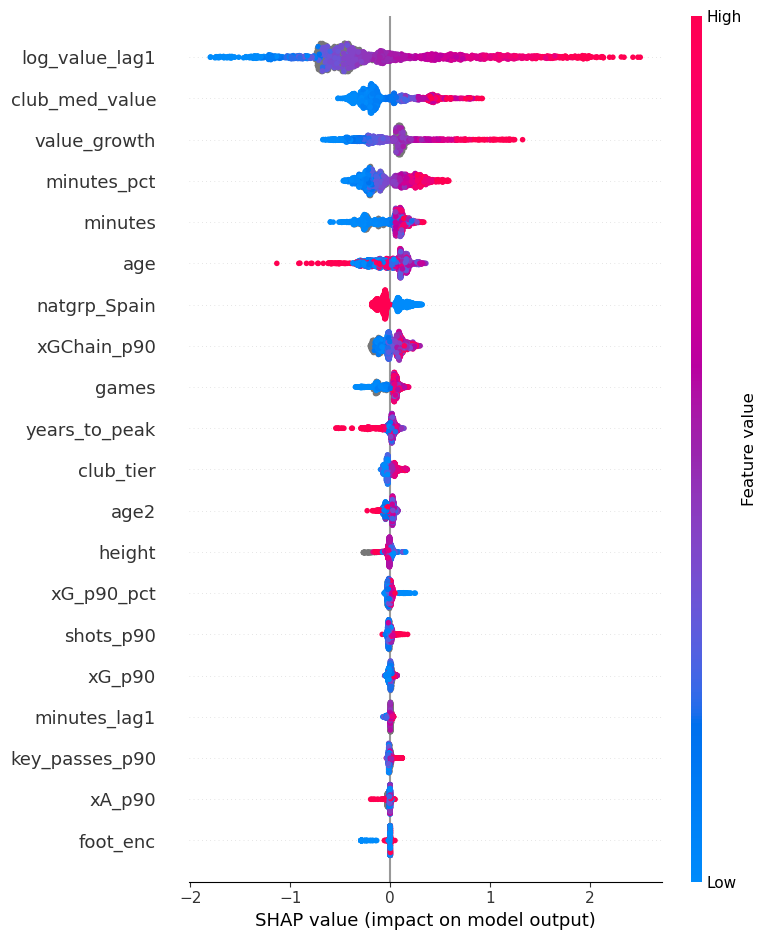

In [4]:
from src.features.engineer import select_features

X_test = select_features(results)

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "shap_summary.png", dpi=150)
plt.show()

## 4. Jogadores mais sub e sobrevalorizados

`error_pct` positivo = o modelo acha que o jogador vale mais do que o
Transfermarkt diz (potencialmente subvalorizado); negativo = o oposto. Isso
é o mesmo cálculo que `compute_undervalue_score()` faz para o app, só que em
pontos percentuais em vez de fração.

In [5]:
cols_show = ["player_name", "year", "club", "pos_group", "age",
             "market_value", "pred_value", "error_pct"]


def fmt(df):
    return df[cols_show].assign(
        market_value=lambda d: (d["market_value"] / 1e6).round(1).astype(str) + "M",
        pred_value=lambda d: (d["pred_value"] / 1e6).round(1).astype(str) + "M",
        error_pct=lambda d: d["error_pct"].round(0).astype(int).astype(str) + "%",
    )


print("=== TOP 10 SUBVALORIZADOS (modelo acha que valem mais) ===")
display(fmt(results.nlargest(10, "error_pct")))

print("\n=== TOP 10 SOBREVALORIZADOS (modelo acha que valem menos) ===")
display(fmt(results.nsmallest(10, "error_pct")))

=== TOP 10 SUBVALORIZADOS (modelo acha que valem mais) ===


,player_name,year,club,pos_group,age,market_value,pred_value,error_pct
289,Antonio Martínez,2025,Elche CF,MID,19.0,0.0M,3.4M,13597%
159,Joaquín Panichelli,2023,Deportivo Alavés,ATT,21.0,0.0M,1.3M,5027%
4053,Jordi Martín,2023,Getafe CF,DEF,22.0,0.0M,1.9M,3761%
5909,Ibra Sow,2023,Sevilla FC,ATT,16.0,0.0M,0.6M,2389%
6013,Sebastian Wade,2024,RCD Mallorca,DEF,21.0,0.0M,0.6M,2276%
187,Pablo Agudín,2025,Real Oviedo,MID,18.0,0.0M,0.5M,1998%
231,Mykyta Aleksandrov,2025,Getafe CF,ATT,21.0,0.0M,0.5M,1832%
4965,Jon Aramburu,2023,Real Sociedad,DEF,21.0,0.3M,5.5M,1749%
5071,Isaac Romero,2023,Sevilla FC,ATT,23.0,0.4M,7.3M,1714%
5921,Piri,2024,CD Leganés,ATT,21.0,0.0M,0.4M,1688%



=== TOP 10 SOBREVALORIZADOS (modelo acha que valem menos) ===


,player_name,year,club,pos_group,age,market_value,pred_value,error_pct
6153,Samu Aghehowa,2023,Deportivo Alavés,ATT,19.0,20.0M,0.3M,-99%
5595,Álvaro Carreras,2025,Real Madrid,DEF,22.0,60.0M,0.9M,-99%
5782,Dean Huijsen,2024,Real Madrid,DEF,19.0,18.0M,0.4M,-98%
2747,Kylian Mbappé,2024,Real Madrid,ATT,26.0,160.0M,4.3M,-97%
5594,Álvaro Carreras,2023,Granada CF,DEF,20.0,7.0M,0.2M,-97%
4472,Hannibal,2023,Sevilla FC,MID,20.0,12.0M,0.5M,-96%
2450,Trent Alexander-Arnold,2024,Real Madrid,DEF,26.0,75.0M,4.5M,-94%
5525,Pablo Barrios,2023,Atlético de Madrid,MID,20.0,25.0M,1.7M,-93%
3682,Max Aarons,2024,Valencia CF,DEF,24.0,16.0M,1.2M,-92%
154,Fer López,2025,Celta de Vigo,MID,21.0,16.0M,1.2M,-92%


## 5. O que já foi salvo

`train_main()` já gravou tudo — nada mais para salvar aqui:

- `models/xgb_model.pkl` — dict `{"model": ..., "features": FEATURE_COLS}`;
  use `src.models.predict.load_model()` para abrir, não `pickle.load` puro.
- `data/test_predictions.parquet` — igual a `results` acima.
- `outputs/pred_vs_real.png`, `outputs/shap_summary.png` — gerados por este
  notebook, gitignored (regenere rodando este notebook de novo).